# ABCMB

## Setup

In [1]:
import sys
sys.path.append('..')

from ABCMB.main import Model
import ABCMB.spectrum as spectrum

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

## Setting up a `Model`

ABCMB is object-oriented, with most calculations running through an instance of `ABCMB.main.Model`.  There are a number of run options that can be specified at initialization; for now, let's specify `ellmin` and `ellmax` (the boundary `ell`s at which to output power spectra), and make sure `lensing` is turned off for our demo.

In [2]:
model = Model(ellmin=2, ellmax=2500, lensing=False)

Once initialized, our instance of `Model` can be used for calculations.  It expects a dictionary of parameters when called; for now we'll specify an empty dictionary to run with the default options.

In [3]:
params = {}

`Model.run_cosmology` sets up background quantities (like $x_e$ and $H$), uses those background quantities to compute the evolution of perturbations, and then finally integrates the resulting transfer function to get $C_{\ell}$s. 

In [8]:
ABC_ell, ABC_Cls = model.run_cosmology(params)
ABC_tt = ABC_Cls[0] 
ABC_te = ABC_Cls[1] 
ABC_ee = ABC_Cls[2] 

We can plot the result:

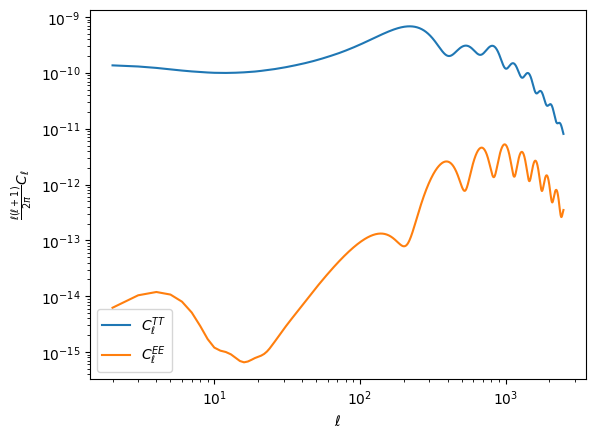

In [10]:
plt.loglog(ABC_ell, ABC_ell * (ABC_ell+1)/(2 * jnp.pi) * ABC_tt,label=r'$C_{\ell}^{TT}$')
plt.loglog(ABC_ell, ABC_ell * (ABC_ell+1)/(2 * jnp.pi) * ABC_ee,label=r'$C_{\ell}^{EE}$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{\ell(\ell + 1)}{2\pi} C_{\ell}$')
plt.legend()

## Specifying params and run options

`Model` has a number of options that can be specified at initialization.  Attempting to change these options will trigger recompilation when `run_cosmology` is called.  See companion paper for a full list of options.

Let's add massive neutrinos, and change the `bbn_type` to `Table` to infer `params['YHe']` from `params['omega_b']` and `params['Neff']`:

In [15]:
model2 = Model(ellmin=2, ellmax=2500, lensing=False, has_MassiveNeutrinos=False, bbn_type='Table')

The parameters dictionary can be changed without triggering recompilation, as long as all inputs to the same variable have the same `dtype` and `shape`.  It is recommended that inputs be wrapped in `jnp.array` to avoid recompilation.  We can change some parameter values:

In [16]:
params = {
    'h': jnp.array(0.60), # hubble
    'omega_cdm': jnp.array(0.1293), # CDM density
    'omega_b': jnp.array(0.0216), # baryon density
    'Neff': jnp.array(3.5)
}

In [17]:
ABC_ell2, ABC_Cls2 = model2.run_cosmology(params)
ABC_tt2 = ABC_Cls2[0] 
ABC_te2 = ABC_Cls2[1] 
ABC_ee2 = ABC_Cls2[2] 

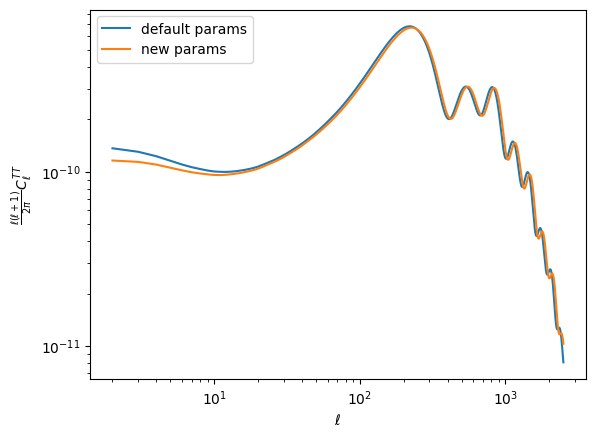

In [18]:
plt.loglog(ABC_ell, ABC_ell * (ABC_ell+1)/(2 * jnp.pi) * ABC_tt,label='default params')
plt.loglog(ABC_ell2, ABC_ell2 * (ABC_ell2+1)/(2 * jnp.pi) * ABC_tt2,label='new params')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{\ell(\ell + 1)}{2\pi} C_{\ell}^{TT}$')
plt.legend()

## Other modules

If you want to work returns beyond the CMB power spectrum, like the perturbations themselves, the sound horizon at decoupling, etc, you have a few options.  You can specify the field `return_PTBG` when intializing `Model` to `True`, so that quantities associated with these modules are also accessible after solving for the CMB power spectrum:

In [20]:
model_PTBG = Model(ellmin=2, ellmax=2500, bbn_type='Table', return_PTBG = True)

In [21]:
ell, Cl, PT, BG = model_PTBG.run_cosmology(params)

# extract Cl spectra in the usual way
Cl_tt = Cl[0] 
Cl_te = Cl[1] 
Cl_ee = Cl[2] 

# print out sound horizon at decoupling in Mpc given input params
print(BG.rs_d())

143.14738011863716


`Model` also has standalone modules to run only the `Background` and `Perturbations` modules without running `SpectrumSolver` to get the full spectrum of $C_{\ell}$s.

It's important that you either specify derived parameters yourself, or augment your parameters dict with derived parameters using `add_derived_parameters` before running these modules standalone.

In [10]:
# let's keep using the same model2
params = {} # default params
params_full = model2.add_derived_parameters(params) # add derived parameters to dict

We can peek at `params_full` to verify all of the parameters we expect are there:

In [11]:
params_full

{'Neff': Array(3.044, dtype=float64, weak_type=True),
 'h': Array(0.7, dtype=float64, weak_type=True),
 'omega_cdm': Array(0.12, dtype=float64, weak_type=True),
 'omega_b': Array(0.02238, dtype=float64, weak_type=True),
 'A_s': Array(2.e-09, dtype=float64, weak_type=True),
 'n_s': Array(0.965, dtype=float64, weak_type=True),
 'TCMB0': Array(0.00023487, dtype=float64, weak_type=True),
 'T_nu': Array(0.00016819, dtype=float64, weak_type=True),
 'T_ncdm': Array(0.71611, dtype=float64, weak_type=True),
 'N_ncdm': Array(0., dtype=float64, weak_type=True),
 'm_ncdm': Array(0., dtype=float64, weak_type=True),
 'z_reion': Array(11., dtype=float64, weak_type=True),
 'Delta_z_reion': Array(0.5, dtype=float64, weak_type=True),
 'z_reion_He': Array(3.5, dtype=float64, weak_type=True),
 'Delta_z_reion_He': Array(0.5, dtype=float64, weak_type=True),
 'omega_m': Array(0.14238, dtype=float64, weak_type=True),
 'R_b': Array(0.157185, dtype=float64, weak_type=True),
 'omega_g': Array(2.47297425e-05, dty

In [13]:
# now call get_PTBG to run background/perturbations
PT, BG = model2.get_PTBG(params_full)

In [14]:
# print out sound horizon at decoupling in Mpc given these params
BG.rs_d()

Array(146.85375974, dtype=float64)

Text(0, 0.5, '$\\frac{\\bar\\rho_{\\gamma} - \\rho_{\\gamma}}{\\bar\\rho_{\\gamma}}$')

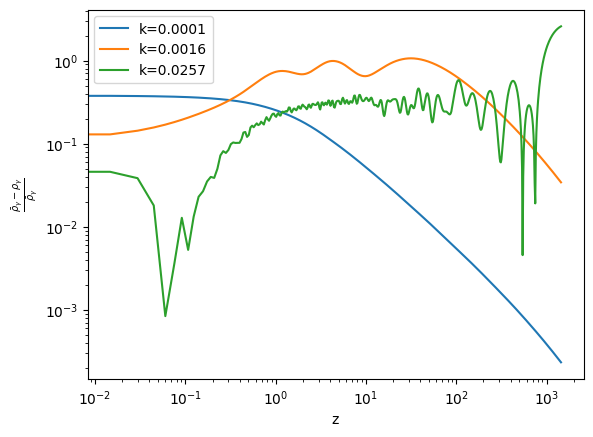

In [15]:
# plot the photon perturbation as a function of redshift for a couple different k's
for k_ind in [10,100,200]:
    plt.loglog(jnp.exp(-PT.lna)-1,jnp.abs(PT.delta_g[:,k_ind]),label="k={k:.4f}".format(k=PT.k[k_ind]))
plt.legend()
plt.xlabel('z')
plt.ylabel(r'$\frac{\bar\rho_{\gamma} - \rho_{\gamma}}{\bar\rho_{\gamma}}$')

## Matter power spectrum

`Model` has a submodule called `SpectrumSolver`, which is responsible for computing the matter and CMB power spectra.  We can access the linear matter power spectrum by calling `model2.SS.Pk_lin`, which requires an output `PerturbationsTable` from `get_PTBG`:

Text(0, 0.5, 'P(k)')

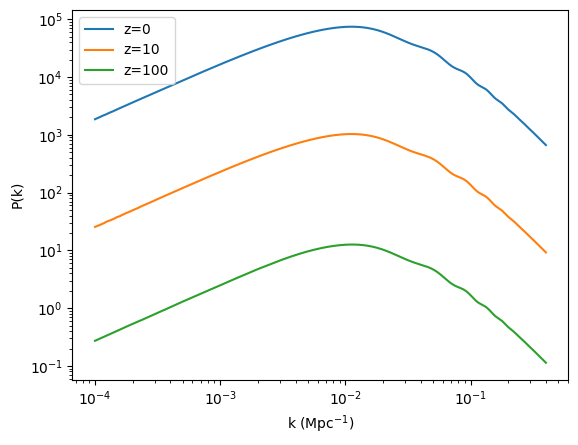

In [16]:
# inputs are desired k in Mpc^{-1}, desired redshift, PerturbationsTable, and parameters dict
for z in [0,10,100]:
    plt.loglog(PT.k, model2.SS.Pk_lin(PT.k, z, PT, params_full), label="z={}".format(z))
plt.legend()
plt.xlabel('k (Mpc$^{-1}$)')
plt.ylabel('P(k)')

We can also plot in terms of $h \textrm{Mpc}^{-1}$, but note `Pk_lin` expects input $k$s to be in $\textrm{Mpc}^{-1}$:

Text(0, 0.5, 'P(k)')

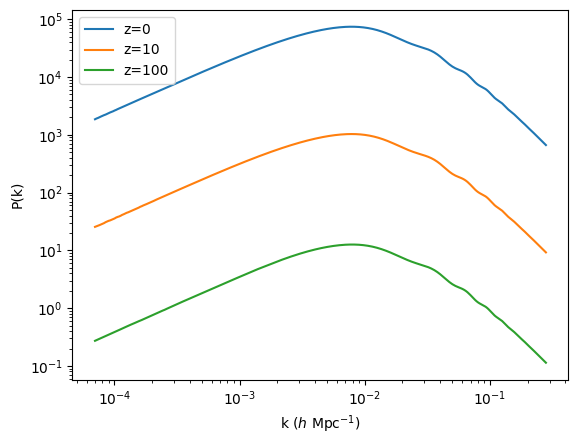

In [17]:
for z in [0,10,100]:
    plt.loglog(params_full['h']*PT.k, model2.SS.Pk_lin(PT.k, z, PT, params_full), label="z={}".format(z))
plt.legend()
plt.xlabel('k ($h$ Mpc$^{-1}$)')
plt.ylabel('P(k)')